# Multimodal RAG Implementation Guide

This notebook demonstrates a complete implementation of Multimodal Retrieval-Augmented Generation (RAG) that can process PDFs containing both text and images. The system uses CLIP embeddings for unified text and image retrieval, combined with OpenAI's GPT-4V for multimodal question answering.

## Process Overview

### 1. Setup and Dependencies
- **Libraries Used**:
  - `PyMuPDF (fitz)`: PDF processing and image extraction
  - `transformers`: CLIP model for unified embeddings
  - `LangChain`: RAG pipeline components
  - `FAISS`: Vector store for similarity search
  - `PIL`: Image processing
  - `torch`: Deep learning framework

### 2. Core Components

#### A. CLIP Model Initialization
- **Model**: `openai/clip-vit-base-patch32`
- **Purpose**: Creates unified embeddings for both text and images in the same vector space
- **GPU Support**: Automatically detects and uses CUDA if available

#### B. Embedding Functions
- **`get_image_embedding()`**: Converts images to CLIP embeddings
- **`get_text_embedding()`**: Converts text to CLIP embeddings
- **Key Features**: 
  - Proper tensor handling and device management
  - L2 normalization for better similarity computation
  - Error handling for different tensor formats

#### C. PDF Processing Pipeline
1. **Text Processing** (`process_text()`):
   - Extracts text from each PDF page
   - Splits text into chunks using RecursiveCharacterTextSplitter
   - Creates CLIP embeddings for each text chunk
   - Generates Document objects with metadata

2. **Image Processing** (`process_images()`):
   - Extracts images from PDF pages
   - Converts images to base64 for GPT-4V compatibility
   - Creates CLIP embeddings for image content
   - Stores images in a data store for later retrieval

### 3. Vector Store Creation
- **Implementation**: FAISS vector store
- **Data**: Unified embeddings from both text and images
- **Benefits**: Fast similarity search across multimodal content

### 4. Retrieval System
- **Function**: `retrieve_multimodal()`
- **Process**:
  1. Convert user query to CLIP embedding
  2. Perform similarity search in vector store
  3. Return top-k most relevant documents (text + images)

### 5. Multimodal Response Generation
- **Function**: `create_multimodal_message()`
- **Process**:
  1. Separates retrieved documents by type (text/image)
  2. Formats text context with page numbers
  3. Includes base64-encoded images for GPT-4V
  4. Creates properly structured message for LLM

### 6. Complete RAG Pipeline
- **Function**: `multimodal_pdf_rag_pipeline()`
- **Process**:
  1. Retrieve relevant documents using CLIP similarity
  2. Create multimodal message with text and images
  3. Send to GPT-4V for final answer generation
  4. Return comprehensive response with context info

## Key Features
- ✅ **Unified Embedding Space**: CLIP enables seamless text-image retrieval
- ✅ **GPU Acceleration**: Automatic CUDA detection and usage
- ✅ **Robust Error Handling**: Handles various tensor formats and edge cases
- ✅ **Chunk-based Processing**: Efficient text processing with configurable chunk sizes
- ✅ **Base64 Image Support**: Direct integration with GPT-4V
- ✅ **Metadata Tracking**: Maintains page numbers and document types
- ✅ **Flexible Retrieval**: Configurable similarity search parameters

## Usage Examples
The notebook includes test queries demonstrating:
- Chart analysis from visual content
- Document summarization combining text and images
- Visual element identification

This implementation provides a complete foundation for building applications that need to understand and reason about documents containing mixed content types.

### Multimodal RAG (PDF With Images)

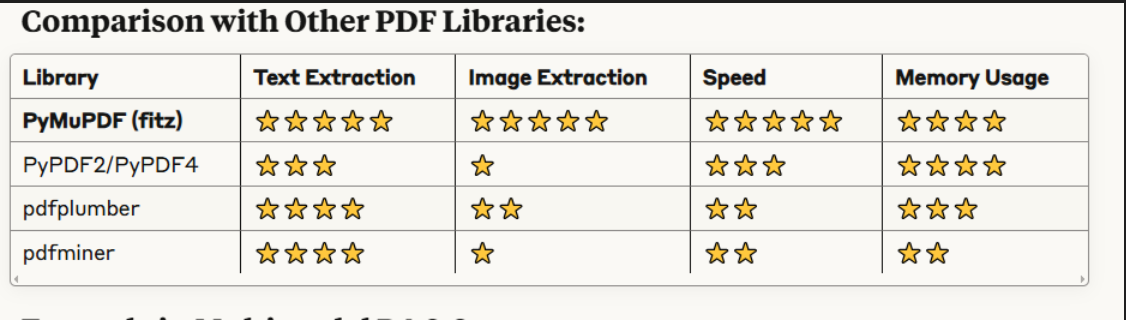

In [ ]:
import fitz  # PyMuPDF
from langchain_core.documents import Document
from transformers import CLIPProcessor, CLIPModel
from PIL import Image
import torch
import numpy as np
from langchain.chat_models import init_chat_model
from langchain_core.prompts import PromptTemplate
from langchain.schema.messages import HumanMessage
from sklearn.metrics.pairwise import cosine_similarity
import os
import base64
import io
from langchain_text_splitters import RecursiveCharacterTextSplitter
from langchain_community.vectorstores import FAISS

In [2]:
# device = "cuda" if torch.cuda.is_available() else "cpu"
# device

# Check if GPU is available
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"Using device: {device}")

# Move tensors/models to GPU
tensor = torch.randn(3, 3).to(device)

Using device: cuda


### 2. Core Components

#### A. CLIP Model Initialization
- **Model**: `openai/clip-vit-base-patch32`
- **Purpose**: Creates unified embeddings for both text and images in the same vector space
- **GPU Support**: Automatically detects and uses CUDA if available

In [3]:
### Load CLIP model and processor

import os
from dotenv import load_dotenv
load_dotenv()

device = "cuda" if torch.cuda.is_available() else "cpu"
# device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')

os.environ["GPT-4-MINI_API_KEY"] = os.getenv("GPT-4-MINI_API_KEY")

## Initialize CLIP model for unified embeddings (using safetensors to avoid PyTorch version requirement)
clip_model = CLIPModel.from_pretrained("openai/clip-vit-base-patch32", use_safetensors=True).to(device)
clip_processor = CLIPProcessor.from_pretrained("openai/clip-vit-base-patch32")
clip_model.eval()

Loading weights:   0%|          | 0/398 [00:00<?, ?it/s]

CLIPModel LOAD REPORT from: openai/clip-vit-base-patch32
Key                                  | Status     |  | 
-------------------------------------+------------+--+-
vision_model.embeddings.position_ids | UNEXPECTED |  | 
text_model.embeddings.position_ids   | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.
The image processor of type `CLIPImageProcessor` is now loaded as a fast processor by default, even if the model checkpoint was saved with a slow processor. This is a breaking change and may produce slightly different outputs. To continue using the slow processor, instantiate this class with `use_fast=False`. 


CLIPModel(
  (text_model): CLIPTextTransformer(
    (embeddings): CLIPTextEmbeddings(
      (token_embedding): Embedding(49408, 512)
      (position_embedding): Embedding(77, 512)
    )
    (encoder): CLIPEncoder(
      (layers): ModuleList(
        (0-11): 12 x CLIPEncoderLayer(
          (self_attn): CLIPAttention(
            (k_proj): Linear(in_features=512, out_features=512, bias=True)
            (v_proj): Linear(in_features=512, out_features=512, bias=True)
            (q_proj): Linear(in_features=512, out_features=512, bias=True)
            (out_proj): Linear(in_features=512, out_features=512, bias=True)
          )
          (layer_norm1): LayerNorm((512,), eps=1e-05, elementwise_affine=True)
          (mlp): CLIPMLP(
            (activation_fn): QuickGELUActivation()
            (fc1): Linear(in_features=512, out_features=2048, bias=True)
            (fc2): Linear(in_features=2048, out_features=512, bias=True)
          )
          (layer_norm2): LayerNorm((512,), eps=1e-05,

### 2. Core Components

#### B. Embedding Functions
- **`get_image_embedding()`**: Converts images to CLIP embeddings
- **`get_text_embedding()`**: Converts text to CLIP embeddings
- **Key Features**: 
  - Proper tensor handling and device management
  - L2 normalization for better similarity computation
  - Error handling for different tensor formats

In [45]:
# Embedding functions with proper error handling for CLIP model outputs
import torch.nn.functional as F

def get_image_embedding(image_data):
    """Embed an image using CLIP with proper tensor extraction."""
    if isinstance(image_data, str): # If path is provided, read the image
        image = Image.open(image_data).convert("RGB")
    else: # If bytes are provided, read the image from bytes
        image = Image.open(io.BytesIO(image_data)).convert("RGB")

    inputs = clip_processor(images=image, return_tensors="pt")
    # Move input tensors to device
    for k, v in inputs.items():
        if isinstance(v, torch.Tensor):
            inputs[k] = v.to(device)

    with torch.no_grad():
        result = clip_model.get_image_features(**inputs)
        
        # Handle both direct tensor returns and model output objects
        if isinstance(result, torch.Tensor):
            features = result
        else:
            # Extract tensor from model output object
            if hasattr(result, 'pooler_output') and result.pooler_output is not None:
                features = result.pooler_output
            elif hasattr(result, 'image_embeds') and result.image_embeds is not None:
                features = result.image_embeds
            elif hasattr(result, 'last_hidden_state') and result.last_hidden_state is not None:
                features = result.last_hidden_state.mean(dim=1)  # Pool if needed
            else:
                raise AttributeError(f"Cannot extract tensor from {type(result)}. Available attributes: {dir(result)}")
        
        # Normalize the features safely
        features = F.normalize(features, p=2, dim=-1)
    return features.cpu().squeeze().numpy()

def get_text_embedding(text):
    """Embed text using CLIP with proper tensor extraction."""
    inputs = clip_processor(
        text=text,
        return_tensors="pt",
        padding=True,
        truncation=True,
        max_length=77
    )
    
    # Move input tensors to device
    for k, v in inputs.items():
        if isinstance(v, torch.Tensor):
            inputs[k] = v.to(device)

    with torch.no_grad():
        result = clip_model.get_text_features(**inputs)
        
        # Handle both direct tensor returns and model output objects
        if isinstance(result, torch.Tensor):
            text_embedding = result
        else:
            # Extract tensor from model output object
            if hasattr(result, 'pooler_output') and result.pooler_output is not None:
                text_embedding = result.pooler_output
            elif hasattr(result, 'text_embeds') and result.text_embeds is not None:
                text_embedding = result.text_embeds
            elif hasattr(result, 'last_hidden_state') and result.last_hidden_state is not None:
                text_embedding = result.last_hidden_state.mean(dim=1)  # Pool if needed
            else:
                raise AttributeError(f"Cannot extract tensor from {type(result)}. Available attributes: {dir(result)}")
        
        # Ensure proper dimensions for text embeddings
        if text_embedding.dim() == 3:
            text_embedding = text_embedding.mean(dim=1)  # Pool sequence dimension
        
        # Normalize the features safely
        text_embedding = F.normalize(text_embedding, p=2, dim=-1)
    return text_embedding.cpu().squeeze().numpy()

#### C. PDF Processing Pipeline
1. **Text Processing** (`process_text()`):
   - Extracts text from each PDF page
   - Splits text into chunks using RecursiveCharacterTextSplitter
   - Creates CLIP embeddings for each text chunk
   - Generates Document objects with metadata

In [41]:
def process_text(index, page):
    """Process text by splitting it into chunks."""
    text_splitter = RecursiveCharacterTextSplitter(chunk_size=500, chunk_overlap=50)

    embeddings = []
    documents = []

    text = page.get_text()
    if text.strip():  # Only process if there is text
        temp_doc = Document(page_content=text, metadata={"page":index, "type": "text"})

        chunks = text_splitter.split_documents([temp_doc])

        # Embed each chunk using clip
        for chunk in chunks:
            print(type(chunk))
            embedding = get_text_embedding(chunk.page_content)
            embeddings.append(embedding)
            documents.append(chunk)

    
    return embeddings, documents

2. **Image Processing** (`process_images()`):
   - Extracts images from PDF pages
   - Converts images to base64 for GPT-4V compatibility
   - Creates CLIP embeddings for image content
   - Stores images in a data store for later retrieval

In [48]:
    ## process images
    ##Three Important Actions:

    ##Convert PDF image to PIL format
    ##Store as base64 for GPT-4V (which needs base64 images)
    ##Create CLIP embedding for retrieval
def process_images(index, page, doc):
    """Process images by converting them to base64 and embedding them."""
    image_embeddings = []
    image_docs = []
    image_data_store = {}  # To store image data for later embedding

    for img_index, img in enumerate(page.get_images(full=True)):
        xref = img[0]
        base_image = doc.extract_image(xref)
        image_bytes = base_image["image"]

        # Create PIL image
        pil_image = Image.open(io.BytesIO(image_bytes)).convert("RGB")

        # Create a unique key for the image to store in the data store
        image_key = f"page_{index}_img_{img_index}"

        # Convert to base64 for GPT-4V and store in image_data_store
        buffered = io.BytesIO()
        pil_image.save(buffered, format="PNG")
        img_base64 = base64.b64encode(buffered.getvalue()).decode()
        image_data_store[image_key] = img_base64

        # Create CLIP embedding
        embedding = get_image_embedding(image_bytes)
        image_embeddings.append(embedding)

        # Store as Document with readable image reference and proper metadata
        image_doc = Document(
            page_content=f"[Image: {image_key}]",  # Readable reference instead of base64
            metadata={"page": index, "type": "image", "image_id": image_key}  # Use image_id instead of img_index
        )
        image_docs.append(image_doc)

    return image_embeddings, image_docs, image_data_store

In [49]:
## Process PDF and create documents with unified embeddings
def process_pdf(pdf_path):
    doc = fitz.open(pdf_path)

    # Storage of documents and their embeddings
    documents = []
    embeddings = []
    image_data_store = {}  # To store image data for later embedding

    for i, page in enumerate(doc):
        text_embeddings, text_docs = process_text(i, page)
        embeddings.extend(text_embeddings)
        documents.extend(text_docs)

        image_embeddings, image_docs, image_data = process_images(i, page, doc)
        embeddings.extend(image_embeddings)
        documents.extend(image_docs)
        image_data_store.update(image_data)

    return documents, embeddings, image_data_store

In [50]:
## Process PDF
pdf_path="multimodal_sample.pdf"
# Storage for all documents and embeddings
all_docs = []
all_embeddings = []
image_data_store = {}  # Store actual image data for LLM

all_docs, all_embeddings, image_data_store = process_pdf(pdf_path)

<class 'langchain_core.documents.base.Document'>


In [51]:
all_docs

[Document(metadata={'page': 0, 'type': 'text'}, page_content='Annual Revenue Overview\nThis document summarizes the revenue trends across Q1, Q2, and Q3. As illustrated in the chart\nbelow, revenue grew steadily with the highest growth recorded in Q3.\nQ1 showed a moderate increase in revenue as new product lines were introduced. Q2 outperformed\nQ1 due to marketing campaigns. Q3 had exponential growth due to global expansion.'),
 Document(metadata={'page': 0, 'type': 'image', 'image_id': 'page_0_img_0'}, page_content='[Image: page_0_img_0]')]

In [52]:
# Create unified FAISS vector store with CLIP embeddings
embeddings_array = np.array(all_embeddings)
embeddings_array

array([[-0.00267244,  0.01283004, -0.05183138, ..., -0.00385082,
         0.02977714, -0.00010685],
       [ 0.01732351, -0.013277  , -0.02427037, ...,  0.08993982,
        -0.00272155,  0.0325306 ]], shape=(2, 512), dtype=float32)

In [53]:
(all_docs,embeddings_array)

([Document(metadata={'page': 0, 'type': 'text'}, page_content='Annual Revenue Overview\nThis document summarizes the revenue trends across Q1, Q2, and Q3. As illustrated in the chart\nbelow, revenue grew steadily with the highest growth recorded in Q3.\nQ1 showed a moderate increase in revenue as new product lines were introduced. Q2 outperformed\nQ1 due to marketing campaigns. Q3 had exponential growth due to global expansion.'),
  Document(metadata={'page': 0, 'type': 'image', 'image_id': 'page_0_img_0'}, page_content='[Image: page_0_img_0]')],
 array([[-0.00267244,  0.01283004, -0.05183138, ..., -0.00385082,
          0.02977714, -0.00010685],
        [ 0.01732351, -0.013277  , -0.02427037, ...,  0.08993982,
         -0.00272155,  0.0325306 ]], shape=(2, 512), dtype=float32))

In [54]:
# Create custom FAISS index since we have precomputed embeddings
vector_store = FAISS.from_embeddings(
    text_embeddings=[(doc.page_content, emb) for doc, emb in zip(all_docs, embeddings_array)],
    embedding=None,  # We're using precomputed embeddings
    metadatas=[doc.metadata for doc in all_docs]
)
vector_store

`embedding_function` is expected to be an Embeddings object, support for passing in a function will soon be removed.


In [55]:
llm = init_chat_model(
    model="openai:gpt-4.1-mini",
    api_key=os.getenv("GPT-4-MINI_API_KEY"),
    base_url="https://models.inference.ai.azure.com"
)
llm

ChatOpenAI(profile={'max_input_tokens': 1047576, 'max_output_tokens': 32768, 'text_inputs': True, 'image_inputs': True, 'audio_inputs': False, 'video_inputs': False, 'text_outputs': True, 'image_outputs': False, 'audio_outputs': False, 'video_outputs': False, 'reasoning_output': False, 'tool_calling': True, 'structured_output': True, 'image_url_inputs': True, 'pdf_inputs': True, 'pdf_tool_message': True, 'image_tool_message': True, 'tool_choice': True}, client=<openai.resources.chat.completions.completions.Completions object at 0x000001873E82A930>, async_client=<openai.resources.chat.completions.completions.AsyncCompletions object at 0x000001873EBBCFE0>, root_client=<openai.OpenAI object at 0x000001873E4D31A0>, root_async_client=<openai.AsyncOpenAI object at 0x000001873EB1ADE0>, model_name='gpt-4.1-mini', model_kwargs={}, openai_api_key=SecretStr('**********'), openai_api_base='https://models.inference.ai.azure.com')

In [56]:
def retrieve_multimodal(query, k=5):
    """Unified retrieval using CLIP embeddings for both text and images."""
    # Embed query using CLIP
    query_embedding = get_text_embedding(query)
    
    # Search in unified vector store
    results = vector_store.similarity_search_by_vector(
        embedding=query_embedding,
        k=k
    )
    
    return results

In [ ]:
def create_multimodal_message(query, retrieved_docs):
    """Create a message with both text and images for GPT-4V."""
    content = []
    
    # Add the query
    content.append({
        "type": "text",
        "text": f"Question: {query}\n\nContext:\n"
    })
    
    # Separate text and image documents
    text_docs = [doc for doc in retrieved_docs if doc.metadata.get("type") == "text"]
    image_docs = [doc for doc in retrieved_docs if doc.metadata.get("type") == "image"]
    
    # Add text context
    if text_docs:
        text_context = "\n\n".join([
            f"[Page {doc.metadata['page']}]: {doc.page_content}"
            for doc in text_docs
        ])
        content.append({
            "type": "text",
            "text": f"Text excerpts:\n{text_context}\n"
        })
    
    # Add images
    for doc in image_docs:
        image_id = doc.metadata.get("image_id")
        if image_id and image_id in image_data_store:
            content.append({
                "type": "text",
                "text": f"\n[Image from page {doc.metadata['page']}]:\n"
            })
            content.append({
                "type": "image_url",
                "image_url": {
                    "url": f"data:image/png;base64,{image_data_store[image_id]}"
                }
            })
    
    # Add instruction
    content.append({
        "type": "text",
        "text": "\n\nPlease answer the question based on the provided text and images."
    })
    
    return HumanMessage(content=content)

In [ ]:
def multimodal_pdf_rag_pipeline(query):
    """Main pipeline for multimodal RAG."""
    # Retrieve relevant documents
    context_docs = retrieve_multimodal(query, k=5)
    
    # Create multimodal message
    message = create_multimodal_message(query, context_docs)
    
    # Get response from GPT-4V
    response = llm.invoke([message])
    
    return response.content


Query: What does the chart on page 1 show about revenue trends?
--------------------------------------------------
Message:content=[{'type': 'text', 'text': 'Question: What does the chart on page 1 show about revenue trends?\n\nContext:\n'}, {'type': 'text', 'text': 'Text excerpts:\n[Page 0]: Annual Revenue Overview\nThis document summarizes the revenue trends across Q1, Q2, and Q3. As illustrated in the chart\nbelow, revenue grew steadily with the highest growth recorded in Q3.\nQ1 showed a moderate increase in revenue as new product lines were introduced. Q2 outperformed\nQ1 due to marketing campaigns. Q3 had exponential growth due to global expansion.\n'}, {'type': 'text', 'text': '\n[Image from page 0]:\n'}, {'type': 'image_url', 'image_url': {'url': ''}}, {'type': 'text', 'text': '\n\nPlease answer the question based on the provided text and images.'}] additional_kwargs={} response_metadata={}
Answer: The chart on page 1 shows a clear upward trend in revenue across the three quar
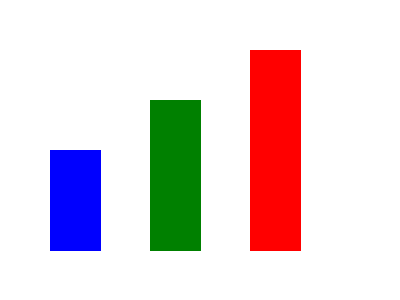
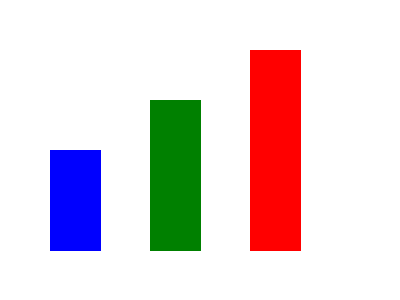
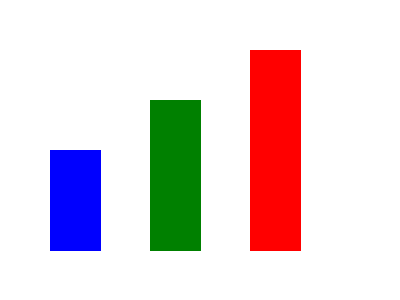

: 

In [ ]:
if __name__ == "__main__":
    # Example queries
    queries = [
        "What does the chart on page 1 show about revenue trends?",
        "Summarize the main findings from the document",
        "What visual elements are present in the document?"
    ]
    
    for query in queries:
        print(f"\nQuery: {query}")
        print("-" * 50)
        answer = multimodal_pdf_rag_pipeline(query)
        print(f"Answer: {answer}")
        print("=" * 70)